In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv(r"C:\Users\Sumit's\Downloads\cibil_score.csv")

In [4]:
df.shape
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 88 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    51336 non-null  int64  
 1   PROSPECTID                    51336 non-null  int64  
 2   Total_TL                      51336 non-null  int64  
 3   Tot_Closed_TL                 51336 non-null  int64  
 4   Tot_Active_TL                 51336 non-null  int64  
 5   Total_TL_opened_L6M           51336 non-null  int64  
 6   Tot_TL_closed_L6M             51336 non-null  int64  
 7   pct_tl_open_L6M               51336 non-null  float64
 8   pct_tl_closed_L6M             51336 non-null  float64
 9   pct_active_tl                 51336 non-null  float64
 10  pct_closed_tl                 51336 non-null  float64
 11  Total_TL_opened_L12M          51336 non-null  int64  
 12  Tot_TL_closed_L12M            51336 non-null  int64  
 13  p

,Unnamed: 0,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,...,PL_utilization,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,Credit_Score
count,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,...,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000
mean,25667.500000,25668.500000,4.858598,2.770415,2.088184,0.736754,0.428919,0.184574,0.089095,0.577542,...,-86556.225194,0.167874,0.190414,0.065182,0.170492,0.056302,-45127.943635,0.271116,0.052887,679.859222
std,14819.571046,14819.571046,7.177116,5.941680,2.290774,1.296717,0.989972,0.297414,0.205635,0.379867,...,34111.414750,0.373758,0.376218,0.235706,0.350209,0.213506,49795.784556,0.444540,0.223810,20.502764
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,0.000000,0.000000,469.000000
25%,12833.750000,12834.750000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.250000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,0.000000,0.000000,669.000000
50%,25667.500000,25668.500000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.556000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333000,0.000000,0.000000,680.000000
75%,38501.250000,38502.250000,5.000000,3.000000,3.000000,1.000000,1.000000,0.308000,0.053000,1.000000,...,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.164250,1.000000,0.000000,691.000000
max,51335.000000,51336.000000,235.000000,216.000000,47.000000,27.000000,19.000000,1.000000,1.000000,1.000000,...,1.708000,1.000000,1.000000,1.000000,1.000000,1.000000,173800.000000,1.000000,1.000000,811.000000


In [5]:
df.isnull().sum()

Unnamed: 0         0
PROSPECTID         0
Total_TL           0
Tot_Closed_TL      0
Tot_Active_TL      0
                  ..
GL_Flag            0
last_prod_enq2     0
first_prod_enq2    0
Credit_Score       0
Approved_Flag      0
Length: 88, dtype: int64

In [6]:
df.shape

(51336, 88)

In [7]:
df = df.replace(-99999, np.nan)

In [8]:
df = df.drop(columns=["Unnamed: 0"])

# normalize column names
df.columns = [col.lower().strip() for col in df.columns]

print(df.shape)
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
df.head()

(51336, 87)
Duplicate rows: 0


,prospectid,total_tl,tot_closed_tl,tot_active_tl,total_tl_opened_l6m,tot_tl_closed_l6m,pct_tl_open_l6m,pct_tl_closed_l6m,pct_active_tl,pct_closed_tl,...,pct_cc_enq_l6m_of_l12m,pct_pl_enq_l6m_of_ever,pct_cc_enq_l6m_of_ever,max_unsec_exposure_inpct,hl_flag,gl_flag,last_prod_enq2,first_prod_enq2,credit_score,approved_flag
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,...,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,...,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,...,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,...,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,...,0.0,0.0,0.0,NaN,0,0,AL,AL,753,P1


In [9]:
X = df.drop(
    columns=["credit_score", "approved_flag"],
    errors="ignore"
)

y = df["credit_score"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [11]:
numeric_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numerical columns: 80
Categorical columns: 5


In [12]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [13]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ]
)

In [15]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [16]:
print("Original features:", X_train.shape[1])
print("Processed features:", X_train_processed.shape[1])

Original features: 85
Processed features: 103


In [17]:
pca = PCA()

X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

In [18]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[1.33203587e-01 9.65957560e-02 6.24602727e-02 5.34219191e-02
 4.00672470e-02 3.83205057e-02 3.20703620e-02 3.16746024e-02
 3.00164963e-02 2.79482429e-02 2.60519061e-02 2.39996697e-02
 2.07434872e-02 1.97646458e-02 1.78797347e-02 1.66367623e-02
 1.61458983e-02 1.52160317e-02 1.51136706e-02 1.28869307e-02
 1.24503497e-02 1.22269840e-02 1.22111482e-02 1.20512346e-02
 1.18638144e-02 1.12782339e-02 1.04093394e-02 9.87004773e-03
 9.32647681e-03 9.11243253e-03 8.77246633e-03 8.49610687e-03
 8.20740162e-03 7.79855397e-03 7.29116173e-03 7.08632363e-03
 6.19010316e-03 6.01796612e-03 5.68155045e-03 5.03015434e-03
 4.80470909e-03 4.61748534e-03 4.35394439e-03 4.17337303e-03
 3.79900951e-03 3.67452923e-03 3.57654460e-03 3.47374119e-03
 3.20802912e-03 3.11312400e-03 3.02965369e-03 2.86399838e-03
 2.78044744e-03 2.52311351e-03 2.47364157e-03 2.39977472e-03
 2.34084900e-03 2.27657294e-03 1.99680145e-03 1.92300344e-03
 1.84151928e-03 1.59931774e-03 1.53773471e-03 1.53100887e-03
 1.39938232e-03 1.330626

In [19]:
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print(cumulative_variance)

[0.13320359 0.22979934 0.29225962 0.34568153 0.38574878 0.42406929
 0.45613965 0.48781425 0.51783075 0.54577899 0.5718309  0.59583057
 0.61657405 0.6363387  0.65421843 0.6708552  0.6870011  0.70221713
 0.7173308  0.73021773 0.74266808 0.75489506 0.76710621 0.77915744
 0.79102126 0.80229949 0.81270883 0.82257888 0.83190536 0.84101779
 0.84979026 0.85828636 0.86649376 0.87429232 0.88158348 0.8886698
 0.89485991 0.90087787 0.90655942 0.91158958 0.91639429 0.92101177
 0.92536572 0.92953909 0.9333381  0.93701263 0.94058917 0.94406291
 0.94727094 0.95038407 0.95341372 0.95627772 0.95905817 0.96158128
 0.96405492 0.9664547  0.96879555 0.97107212 0.97306892 0.97499192
 0.97683344 0.97843276 0.9799705  0.9815015  0.98290089 0.98423151
 0.98551166 0.98674474 0.98789491 0.9889887  0.98998629 0.99085968
 0.99167482 0.99247277 0.99318842 0.99386964 0.99446979 0.99503386
 0.99558425 0.99610887 0.99660535 0.99707681 0.9975131  0.99794425
 0.99828378 0.99861898 0.99893861 0.99924218 0.99952546 0.99974

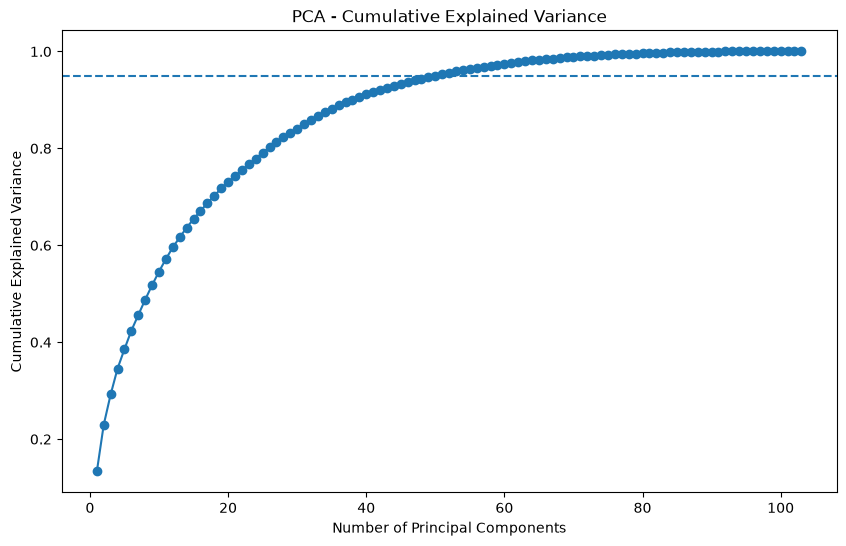

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")

plt.axhline(
    y=0.95,
    linestyle="--"
)

plt.show()

In [21]:
n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print(
    "Number of components required for 95% variance:",
    n_components_95
)

Number of components required for 95% variance: 50


In [22]:
pca_95 = PCA(
    n_components=0.95
)

X_train_pca = pca_95.fit_transform(
    X_train_processed
)

X_test_pca = pca_95.transform(
    X_test_processed
)

In [23]:
print(
    "Original number of features:",
    X_train_processed.shape[1]
)

print(
    "Number of PCA components:",
    X_train_pca.shape[1]
)

Original number of features: 103
Number of PCA components: 50


In [24]:
print(
    "Variance retained:",
    pca_95.explained_variance_ratio_.sum()
)

Variance retained: 0.9503840671357241


In [25]:
feature_names = preprocessor.get_feature_names_out()

components_df = pd.DataFrame(
    pca_95.components_,
    columns=feature_names
)

print(components_df.head())

   num__prospectid  num__total_tl  num__tot_closed_tl  num__tot_active_tl  \
0         0.002067       0.189002            0.143882            0.218454   
1        -0.001346       0.199137            0.220578            0.052459   
2         0.002633      -0.141723           -0.135668           -0.092243   
3         0.004383      -0.063476           -0.003895           -0.187825   
4         0.002746      -0.026174            0.000388           -0.082585   

   num__total_tl_opened_l6m  num__tot_tl_closed_l6m  num__pct_tl_open_l6m  \
0                  0.202259                0.167212              0.071138   
1                 -0.044797                0.063569             -0.166394   
2                 -0.107825               -0.137216             -0.012056   
3                 -0.138796                0.024655             -0.185698   
4                  0.110299                0.207607              0.122195   

   num__pct_tl_closed_l6m  num__pct_active_tl  num__pct_closed_tl  ...  \


In [26]:
pc1 = components_df.iloc[0]

print(
    pc1.abs()
    .sort_values(ascending=False)
    .head(10)
)

num__tot_enq                 0.240865
num__enq_l12m                0.222012
num__total_tl_opened_l12m    0.220867
num__tot_active_tl           0.218454
num__pl_enq                  0.210944
num__enq_l6m                 0.208156
num__unsecured_tl            0.207097
num__total_tl_opened_l6m     0.202259
num__pl_enq_l12m             0.195639
num__total_tl                0.189002
Name: 0, dtype: float64


In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

linear_pca = LinearRegression()

linear_pca.fit(
    X_train_pca,
    y_train
)

y_pred = linear_pca.predict(
    X_test_pca
)

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("PCA Linear Regression")
print("---------------------")
print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

PCA Linear Regression
---------------------
R²: 0.8233207733463913
MAE: 6.811136838088495
RMSE: 8.596725851369893


In [28]:
# ==========================================
# PCA + LOGISTIC REGRESSION
# Target = approved_flag
# ==========================================

X_log = df.drop(
    columns=["approved_flag", "credit_score"],
    errors="ignore"
)

y_log = df["approved_flag"]

In [29]:
X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log,
    y_log,
    test_size=0.20,
    random_state=42,
    stratify=y_log
)

In [30]:
log_numeric_cols = X_log_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

log_categorical_cols = X_log_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical columns:", len(log_numeric_cols))
print("Categorical columns:", len(log_categorical_cols))

Numerical columns: 80
Categorical columns: 5


In [31]:
log_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

log_categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [32]:
log_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            log_numeric_pipeline,
            log_numeric_cols
        ),
        (
            "cat",
            log_categorical_pipeline,
            log_categorical_cols
        )
    ]
)

In [33]:
X_log_train_processed = log_preprocessor.fit_transform(
    X_log_train
)

X_log_test_processed = log_preprocessor.transform(
    X_log_test
)

print(
    "Processed training shape:",
    X_log_train_processed.shape
)

print(
    "Processed testing shape:",
    X_log_test_processed.shape
)

Processed training shape: (41068, 103)
Processed testing shape: (10268, 103)


In [34]:
pca_log = PCA(
    n_components=0.95
)

X_log_train_pca = pca_log.fit_transform(
    X_log_train_processed
)

X_log_test_pca = pca_log.transform(
    X_log_test_processed
)

print(
    "Original features:",
    X_log_train_processed.shape[1]
)

print(
    "PCA components:",
    X_log_train_pca.shape[1]
)

print(
    "Variance retained:",
    pca_log.explained_variance_ratio_.sum()
)

Original features: 103
PCA components: 50
Variance retained: 0.9505111733842687


In [35]:
from sklearn.linear_model import LogisticRegression

In [36]:
logistic_pca_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

logistic_pca_model.fit(
    X_log_train_pca,
    y_log_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [37]:
y_log_pred_pca = logistic_pca_model.predict(
    X_log_test_pca
)

y_log_prob_pca = logistic_pca_model.predict_proba(
    X_log_test_pca
)[:, 1]

In [38]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [39]:
accuracy_log_pca = accuracy_score(
    y_log_test,
    y_log_pred_pca
)

precision_log_pca = precision_score(
    y_log_test,
    y_log_pred_pca,
    average="weighted",
    zero_division=0
)

recall_log_pca = recall_score(
    y_log_test,
    y_log_pred_pca,
    average="weighted",
    zero_division=0
)

f1_log_pca = f1_score(
    y_log_test,
    y_log_pred_pca,
    average="weighted",
    zero_division=0
)

print("PCA + Logistic Regression Results")
print("----------------------------------")
print("Accuracy :", accuracy_log_pca)
print("Precision:", precision_log_pca)
print("Recall   :", recall_log_pca)
print("F1 Score :", f1_log_pca)

PCA + Logistic Regression Results
----------------------------------
Accuracy : 0.7778535255161667
Precision: 0.7446164869890888
Recall   : 0.7778535255161667
F1 Score : 0.7505686765537557


In [40]:
print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_log_test,
        y_log_pred_pca
    )
)


Confusion Matrix:
[[ 832  324    5    0]
 [ 157 6038  173   72]
 [  31  942  258  260]
 [   0  138  179  859]]


In [41]:
print("\nClassification Report:")

print(
    classification_report(
        y_log_test,
        y_log_pred_pca,
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

          P1       0.82      0.72      0.76      1161
          P2       0.81      0.94      0.87      6440
          P3       0.42      0.17      0.25      1491
          P4       0.72      0.73      0.73      1176

    accuracy                           0.78     10268
   macro avg       0.69      0.64      0.65     10268
weighted avg       0.74      0.78      0.75     10268

